In [92]:
import pandas as pd
import matplotlib.pyplot as plt

In [93]:
IMPULSE = 100
open_stats = pd.read_csv(f"../output/open_firstImpulse{IMPULSE}.csv")
open = open_stats.drop(columns=["Adj Close"], errors="ignore")
daily_stats = pd.read_csv("../output/daily_stats.csv")
daily = daily_stats.drop(columns=["Adj Close"], errors="ignore")

results = open.merge(daily, on="Date")
results.head()

,Date,First100,ImpulseMFE,ImpulseMAE,Close,High,Low,Open,Volume,Direction,Extension,Counter
0,2026-04-29,Up,33.50,153.25,27325.25,27414.00,27094.00,27197.25,516846,Bull,216.75,103.25
1,2026-04-30,Down,228.00,230.75,27596.00,27622.75,27163.25,27207.00,701348,Bull,415.75,43.75
2,2026-05-01,Up,184.50,114.75,27835.75,27917.00,27536.25,27631.75,509821,Bull,285.25,95.50
3,2026-05-04,Down,141.75,64.00,27776.00,27965.75,27613.00,27890.00,576727,Bear,277.00,75.75
4,2026-05-05,Up,99.75,56.75,28136.00,28247.00,27731.75,27760.00,458058,Bull,487.00,28.25


In [94]:
results["Outcome"] = "Unknown"

results.loc[
    (
        (results[f"First{IMPULSE}"] == "Up")
        & (results["Direction"] == "Bull")
    )
    |
    (
        (results[f"First{IMPULSE}"] == "Down")
        & (results["Direction"] == "Bear")
    ),
    "Outcome"
] = "Continuation"

results.loc[
    (
        (results[f"First{IMPULSE}"] == "Up")
        & (results["Direction"] == "Bear")
    )
    |
    (
        (results[f"First{IMPULSE}"] == "Down")
        & (results["Direction"] == "Bull")
    ),
    "Outcome"
] = "Reversal"

results.head()

,Date,First100,ImpulseMFE,ImpulseMAE,Close,High,Low,Open,Volume,Direction,Extension,Counter,Outcome
0,2026-04-29,Up,33.50,153.25,27325.25,27414.00,27094.00,27197.25,516846,Bull,216.75,103.25,Continuation
1,2026-04-30,Down,228.00,230.75,27596.00,27622.75,27163.25,27207.00,701348,Bull,415.75,43.75,Reversal
2,2026-05-01,Up,184.50,114.75,27835.75,27917.00,27536.25,27631.75,509821,Bull,285.25,95.50,Continuation
3,2026-05-04,Down,141.75,64.00,27776.00,27965.75,27613.00,27890.00,576727,Bear,277.00,75.75,Continuation
4,2026-05-05,Up,99.75,56.75,28136.00,28247.00,27731.75,27760.00,458058,Bull,487.00,28.25,Continuation


In [95]:
filtered = results[
    results["Outcome"].isin(["Continuation", "Reversal"])
]

In [96]:
summary = (
    filtered["Outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

summary

Outcome
Continuation    74.0
Reversal        26.0
Name: proportion, dtype: float64

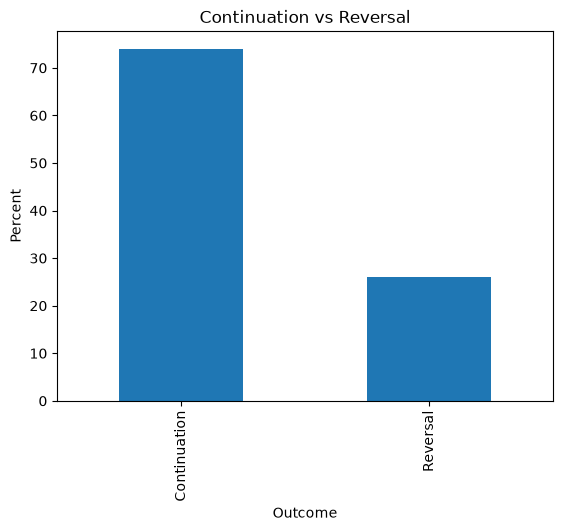

In [97]:
summary.plot(kind="bar")

plt.title("Continuation vs Reversal")
plt.ylabel("Percent")
plt.show()

In [98]:
summary = (
    filtered.groupby("Outcome")
    .agg(
        Count=("Outcome", "size"),
        Percent=("Outcome", lambda x: round(len(x) / len(filtered) * 100, 1)),
        MAE=("Counter", "mean"),
        MFE=("Extension", "mean"),
    )
    .round({
        "MAE": 2,
        "MFE": 2,
    })
)

summary

,Count,Percent,MAE,MFE
Outcome,,,,
Continuation,37,74.0,120.53,497.76
Reversal,13,26.0,178.31,510.63


In [101]:
stats = pd.read_csv("../output/daily_stats.csv")
impulse = pd.read_csv(f"../output/open_firstImpulse{IMPULSE}.csv")

df = stats.merge(impulse, on="Date")

continuation = (
    ((df[f"First{IMPULSE}"] == "Up") & (df["Direction"] == "Bull")) |
    ((df[f"First{IMPULSE}"] == "Down") & (df["Direction"] == "Bear"))
)

reversal = (
    ((df[f"First{IMPULSE}"] == "Up") & (df["Direction"] == "Bear")) |
    ((df[f"First{IMPULSE}"] == "Down") & (df["Direction"] == "Bull"))
)

print(f"Continuation: {continuation.mean():.1%}")
print(f"Reversal:     {reversal.mean():.1%}")

print("\nContinuation")
print(df.loc[continuation, ["ImpulseMFE", "ImpulseMAE"]].median())

print("\nReversal")
print(df.loc[reversal, ["ImpulseMFE", "ImpulseMAE"]].median())

Continuation: 74.0%
Reversal:     26.0%

Continuation
ImpulseMFE    184.5
ImpulseMAE    151.0
dtype: float64

Reversal
ImpulseMFE    103.5
ImpulseMAE    379.0
dtype: float64


In [100]:
print(df[f"First{IMPULSE}"].value_counts())
print()
print(df["Direction"].value_counts())

First100
Up      26
Down    24
Name: count, dtype: int64

Direction
Bull    31
Bear    19
Name: count, dtype: int64
